# Define Help Functions

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import pandas as pd
import copy

BASE_DIR = 'wandb_results'
OUTPUT_DIR = 'figures'

wandb_to_name = {'tdmpc-M0-1': '10% TDMPC', 'tdmpc': '100% TDMPC', 'tap': 'TAP', 'fac': 'Fac-TDMPC'}

def load_results(task_name):
    results = dict()
    file_path = os.path.join(BASE_DIR, f"{task_name}.csv")
    df = pd.read_csv(file_path)
    for i, c in enumerate(df.columns[1::3]):
        for k, v in wandb_to_name.items():
            if k  in c:
                results[v] = {'x': df['Step'], 'y': df.iloc[:, 3*i+1], 'y_min': df.iloc[:, 3*i+2], 'y_max': df.iloc[:, 3*i+3]}
                break
    return results

# smooth function for plots
def smooth(scalars, weight=0.5):  # Weight between 0 and 1
    last = scalars[0]  # First value in the plot (first timestep)
    smoothed = list()
    for point in scalars:
        smoothed_val = last * weight + (1 - weight) * point  # Calculate smoothed value
        smoothed.append(smoothed_val)                        # Save it
        last = smoothed_val                                  # Anchor the last smoothed value
    return smoothed

def plot_curves(exp_name, learned_results, expert_result={}, left=False):
    
    # Initialize figure
    fig, axes = plt.subplots(1, 1, figsize=(7, 6))
    # plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
    
    ax1 = axes
    x_name = "Steps (1e5)"
    y_name = "Episode Return"

    # fixed result
    for expert_name, expert_value in expert_result.items():
        ax1.axhline(y=expert_value, linewidth=2.0, linestyle='--', label='TDMPC', color='black')

    # learning result
    for label_name in wandb_to_name.values():
        values = learned_results[label_name]
        
        xs = values["x"] / 1e5
        ys = values["y"]
        ys_min = values["y_min"]
        ys_max = values["y_max"]

        # M: smooth
        # # M: tricky parts...
        # if exp_name == 'test02' or exp_name == 'test02+': 
        #     ys = (ys - 0.5) * 0.75 + 0.5
            
        # calculate statistics
        x_min, x_max = 0.0, np.max(xs)
        y_min, y_max = 0, 1100.0
            
        # plot setups
        exp_name = exp_name.replace('-', ' ').title()
        ax1.set_title(exp_name, fontsize=30) # , fontstyle='italic')
        ax1.set_xlabel(x_name, fontsize=30)
        ax1.set_ylim((y_min, y_max))
        ax1.set_xlim((x_min, x_max))
        ax1.tick_params(labelsize=20)
        ax1.grid(True, linestyle=':')
        ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))  
            
        # plot
        ax1.plot(xs, ys, linewidth=3.0, label=label_name)
        ax1.fill_between(xs, ys_min, ys_max, alpha=0.1, linewidth=0., edgecolor='none')

        if left:
            ax1.set_ylabel(y_name, fontsize=30)

    # ax1.legend(fontsize=20, loc='lower right') #, bbox_to_anchor=(0.98, 0.1))
    plt.tight_layout()
    
    return fig


def plot_all_curves(all_results):
    
    # Initialize figure
    fig, axes = plt.subplots(3, 4, figsize=(28, 20))
    # plt.ticklabel_format(style='sci',axis='x',scilimits=(0,0))
    
    x_name = "Steps (1e5)"
    y_name = "Episode Return"

    # fixed result
    for i, (task_name, learned_results, expert) in enumerate(all_results):

        # ax id
        ax1 = axes[i//4, i%4]

        # print expert
        for k, v in expert.items():
            ax1.axhline(y=v, linewidth=2.0, linestyle='--', label=k, color='black')

        # print learning result
        for label_name in wandb_to_name.values():
            values = learned_results[label_name]
            
            xs = values["x"] / 1e5
            ys = values["y"]
            ys_min = values["y_min"]
            ys_max = values["y_max"]

            # M: smooth
            # # M: tricky parts...
            # if exp_name == 'test02' or exp_name == 'test02+': 
            #     ys = (ys - 0.5) * 0.75 + 0.5
                
            # calculate statistics
            x_min, x_max = 0.0, np.max(xs)
            y_min, y_max = 0, 1100.0
                
            # plot setups
            task_name = task_name.replace('-', ' ').title()
            if i==0:
                ax1.set_title(task_name, fontsize=30, fontweight="bold") # , fontstyle='italic')
            else:
                ax1.set_title(task_name, fontsize=30) # , fontstyle='italic')
            ax1.set_ylim((y_min, y_max))
            ax1.set_xlim((x_min, x_max))
            ax1.tick_params(labelsize=20)
            ax1.grid(True, linestyle=':')
            ax1.yaxis.set_major_locator(MaxNLocator(nbins=5))  
                
            # plot
            ax1.plot(xs, ys, linewidth=3.0, label=label_name)
            ax1.fill_between(xs, ys_min, ys_max, alpha=0.1, linewidth=0., edgecolor='none')

            if i//4 == 2:
                ax1.set_xlabel(x_name, fontsize=30)
            if i%4 == 0:
                ax1.set_ylabel(y_name, fontsize=30)

    handles, labels = ax1.get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=30, bbox_to_anchor=(0.5, -0.05), loc="lower center", ncol=len(labels))
    plt.tight_layout()
    
    return fig


# Results

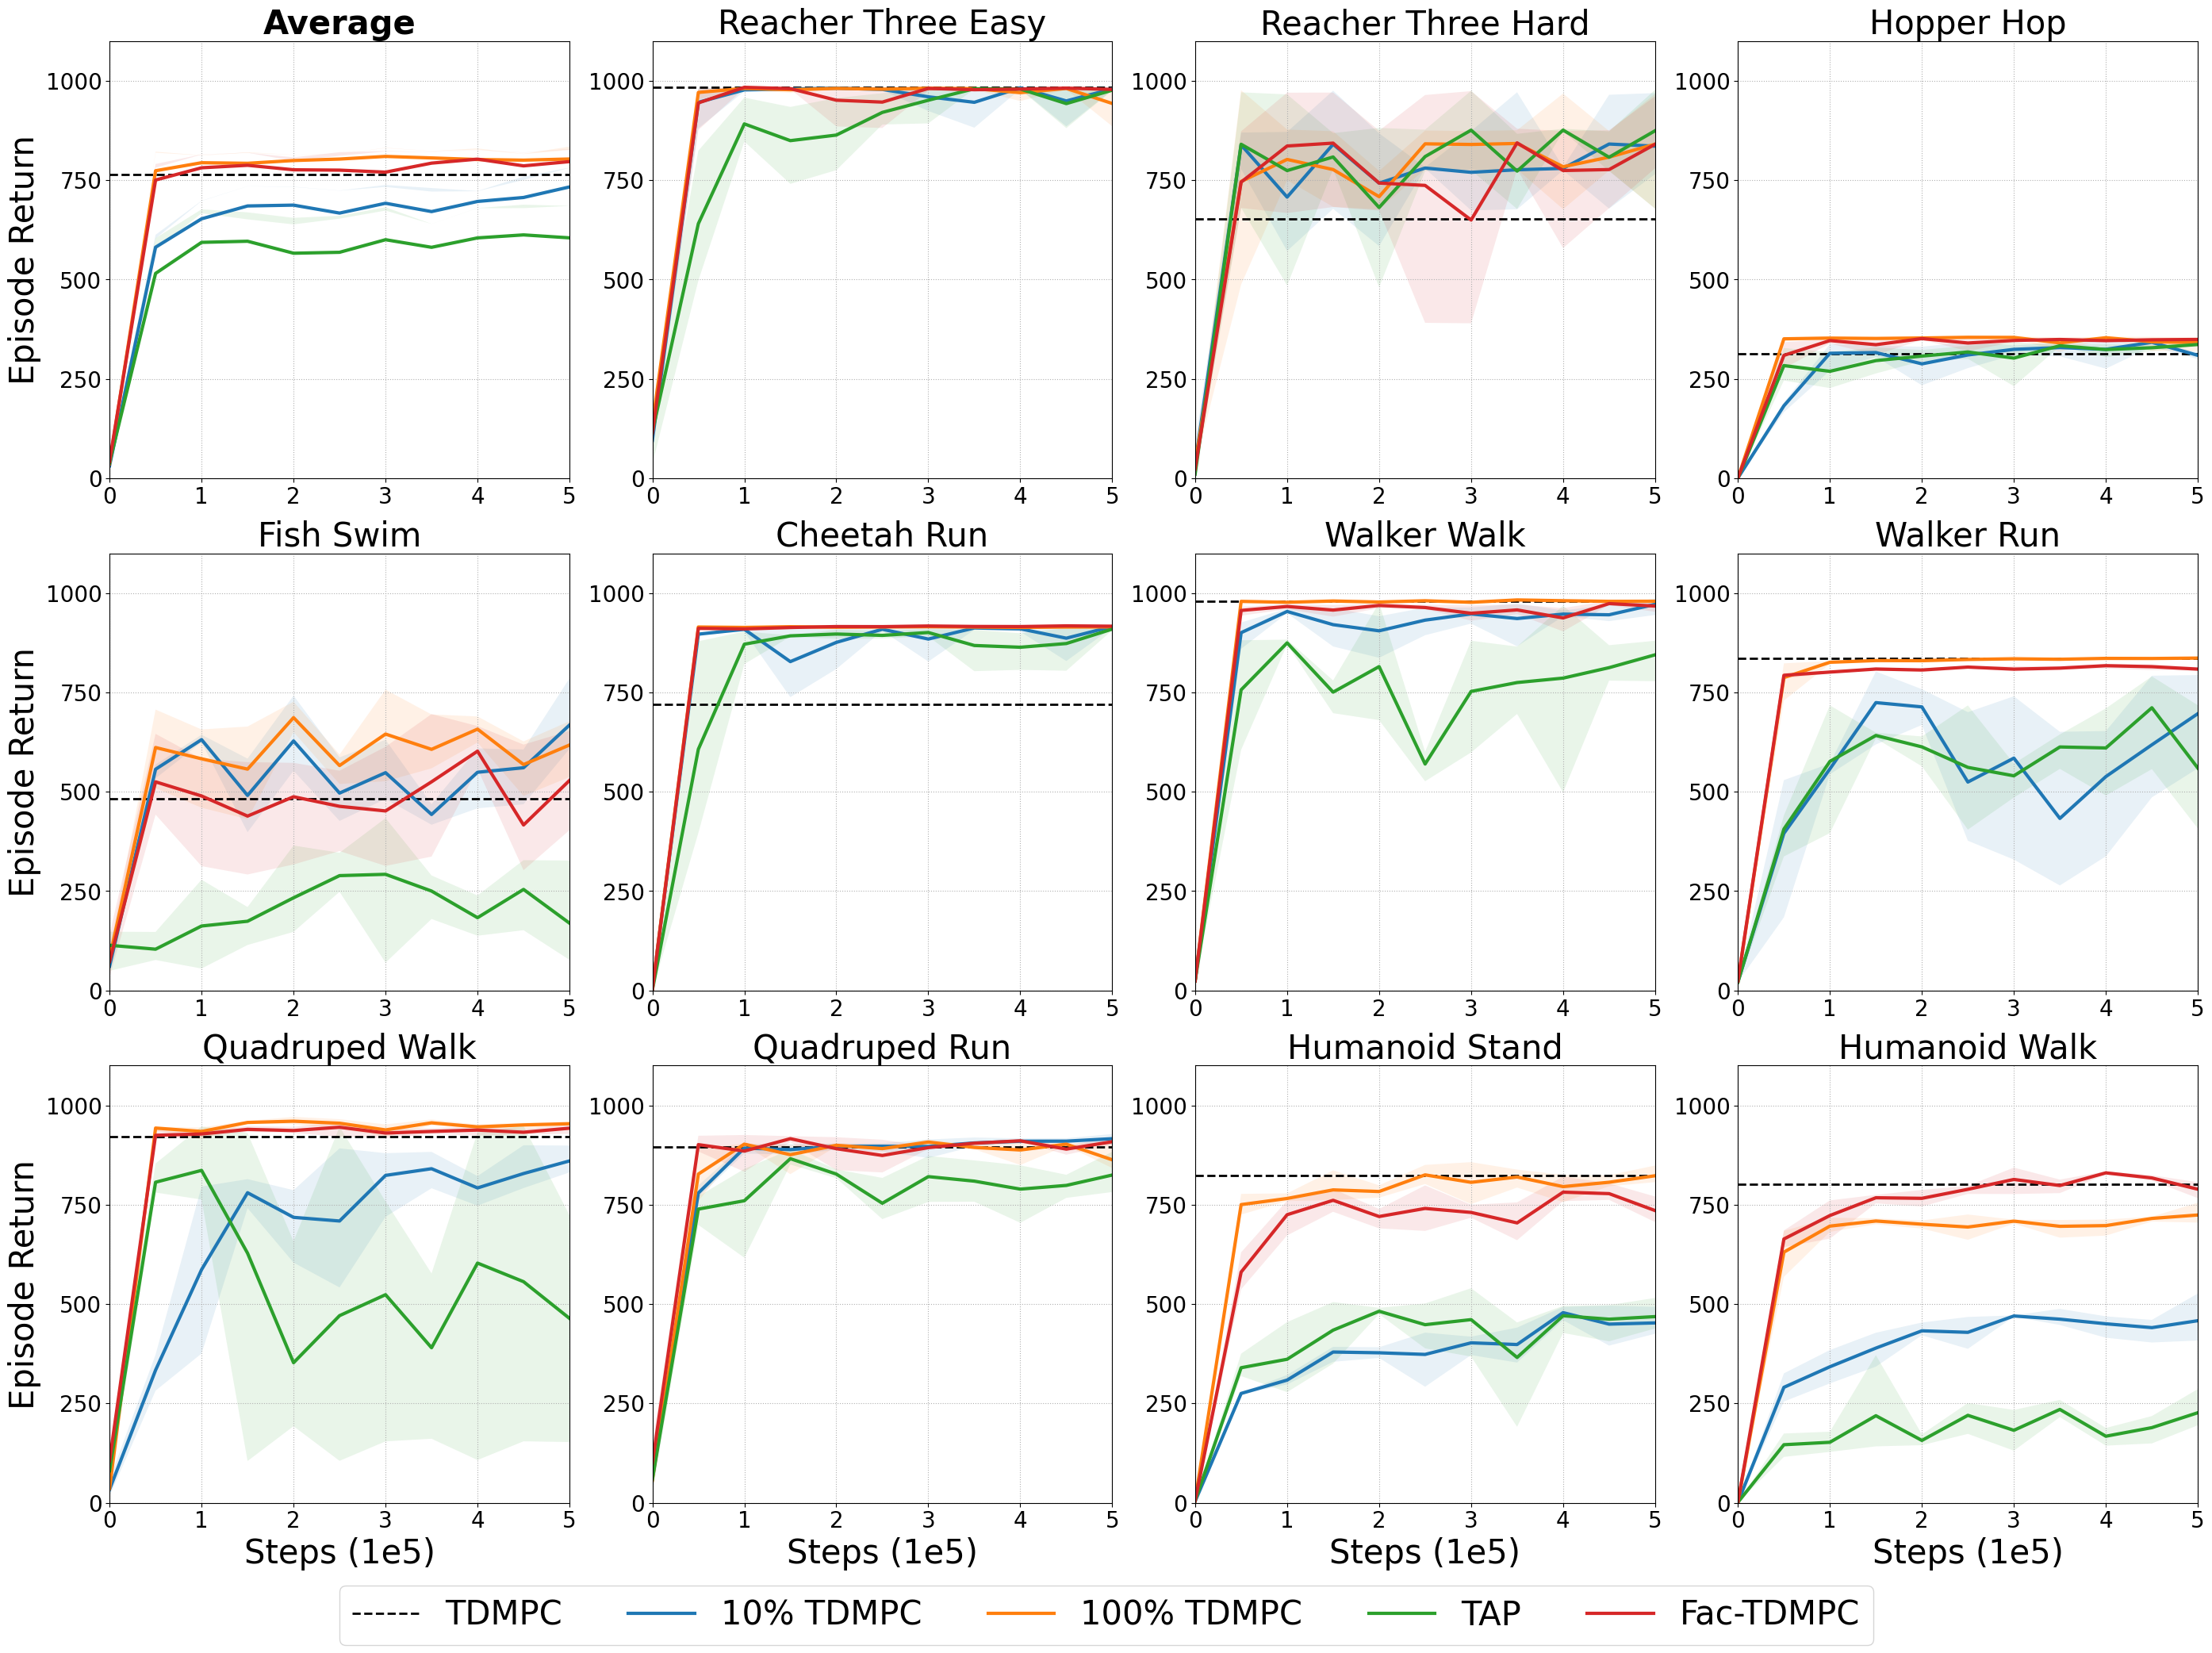

In [4]:
task_expert_results = [['reacher-three-easy', {"TDMPC": 983.1}], ['reacher-three-hard', {"TDMPC": 652.7}], 
               ['hopper-hop', {"TDMPC": 313.5}], ['fish-swim', {"TDMPC": 482.9}],
               ['cheetah-run', {"TDMPC": 721.}], ['walker-walk', {"TDMPC": 979.3}],
               ['walker-run', {"TDMPC": 835.6}], ['quadruped-walk', {"TDMPC": 922.2}],
               ['quadruped-run', {"TDMPC": 894.7}], ['humanoid-stand', {"TDMPC": 823.}],
               ['humanoid-walk', {"TDMPC": 801.}]]

all_results = []
avg_results, avg_expert = None, None
for i, (task_name, expert) in enumerate(task_expert_results):
    results = load_results(task_name)
    all_results.append([task_name, results, expert])
    # fig = plot_curves(task_name, results, expert, left=(i%4==3))
    # merge results
    if avg_expert is None:
        avg_expert = copy.deepcopy(expert)
    else:
        for k, v in expert.items():
            avg_expert[k] = (avg_expert[k]*(i) + v)/(i+1) 
    if avg_results is None:
        avg_results = copy.deepcopy(results)
    else:
        for k, v in results.items():
            avg_results[k]['y'] = (avg_results[k]['y']*(i) + v['y'])/(i+1) 
            avg_results[k]['y_min'] = (avg_results[k]['y_min']*(i) + v['y_max'])/(i+1) 
            avg_results[k]['y_max'] = (avg_results[k]['y_max']*(i) + v['y_max'])/(i+1) 

all_results.insert(0, ['Average', avg_results, avg_expert])
fig = plot_all_curves(all_results)
fig.savefig(OUTPUT_DIR+f'/all_results.png', dpi=300, bbox_inches="tight")

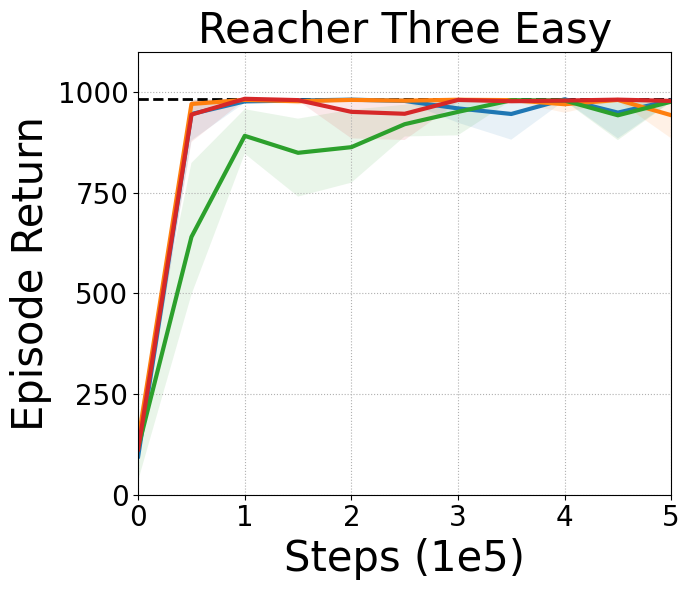

In [27]:
task_name = 'reacher-three-easy'
results = load_results(task_name)
fig = plot_curves(task_name, results, {"TDMPC": 983.1}, left=True)
fig.savefig(OUTPUT_DIR+f'/{task_name}.png', dpi=300)

In [13]:
name = 'reacher-three-hard'
results = load_results(exp_names={'Fac-TDMPC': name})
fig = plot_curves(name, results, {"TDMPC": 652.7})
fig.savefig(OUTPUT_DIR+f'/{name}.png', dpi=300)

TypeError: load_results() got an unexpected keyword argument 'exp_names'

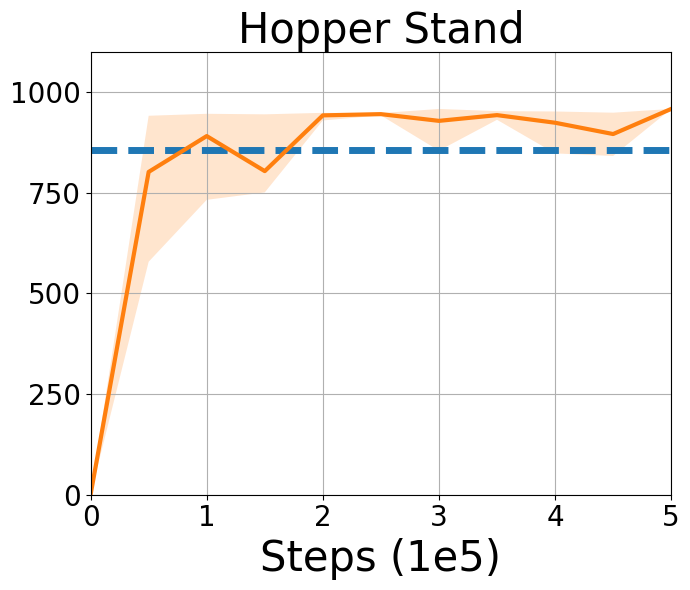

In [159]:
exp_name = "hopper-stand"
expert_value = 855.4
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})

fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)

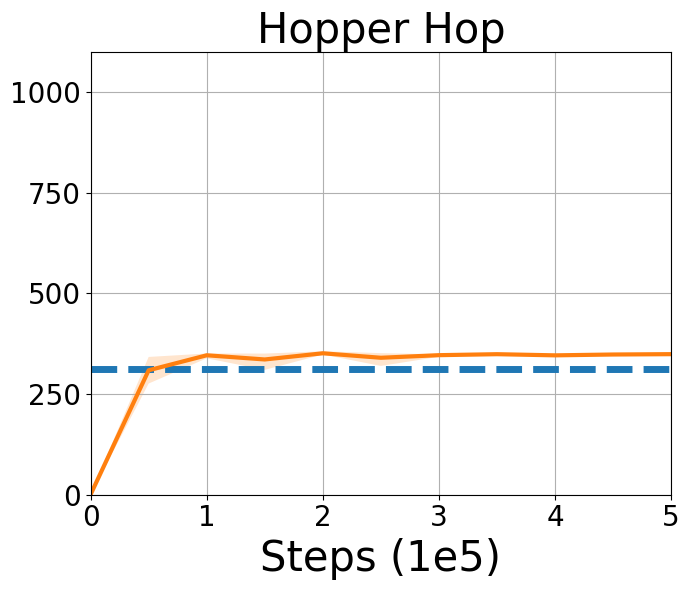

In [160]:
exp_name = "hopper-hop"
expert_value = 313.5
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})

fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)

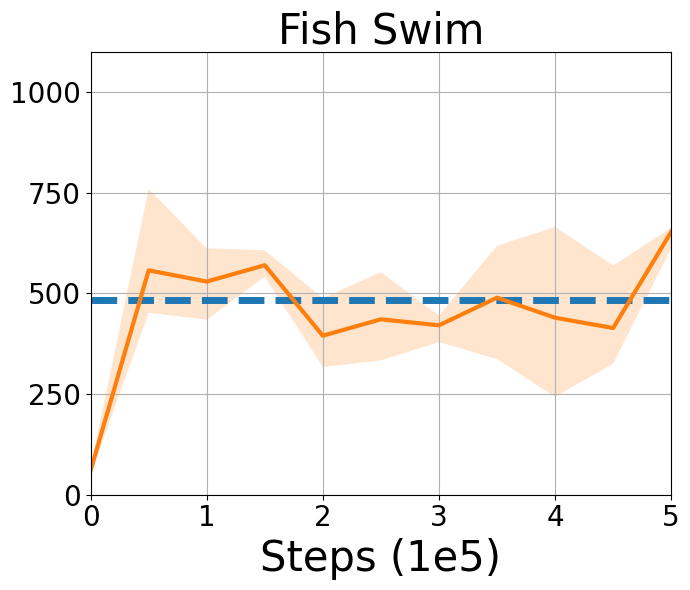

In [161]:
exp_name = "fish-swim"
expert_value = 482.9
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})

fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)

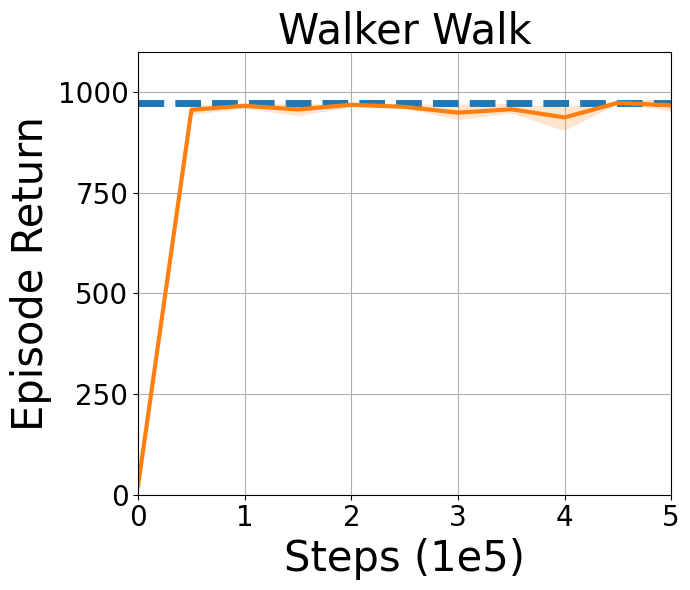

In [156]:
exp_name = "walker-walk"
expert_value = 973.3 # 979.3
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})
fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)


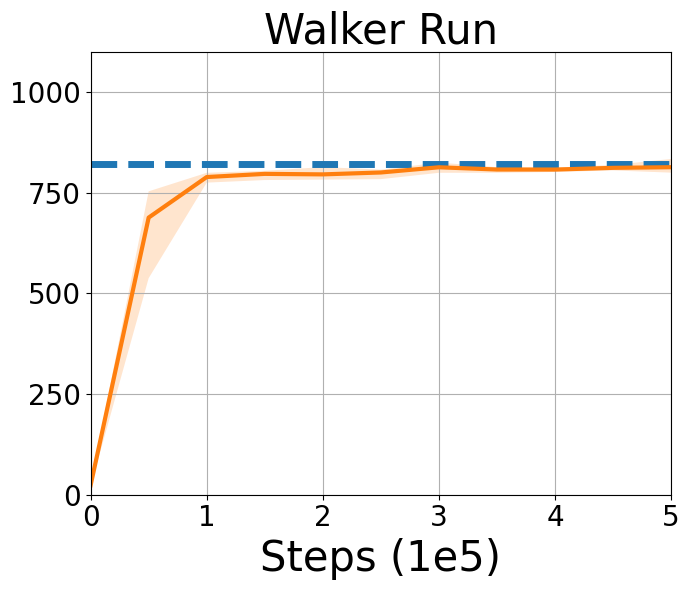

In [175]:
exp_name = "walker-run"
expert_value = 820.6 # 835.6
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})
fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)


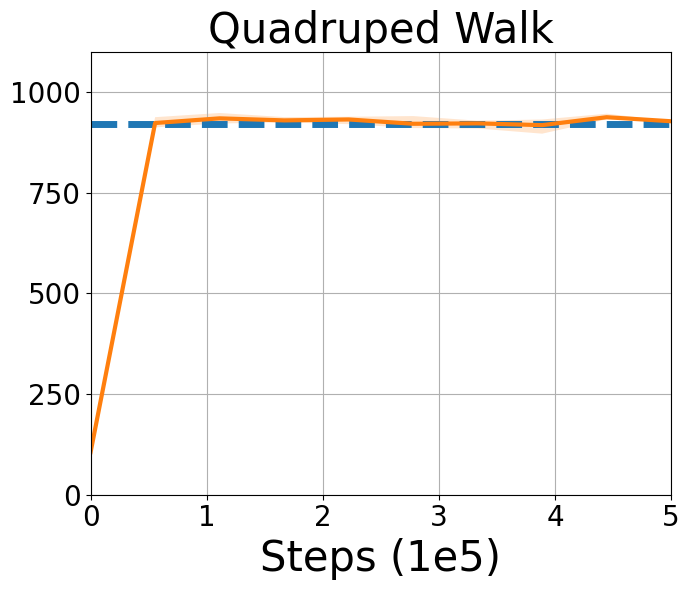

In [170]:
exp_name = "quadruped-walk"
expert_value = 922.2
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})

fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)

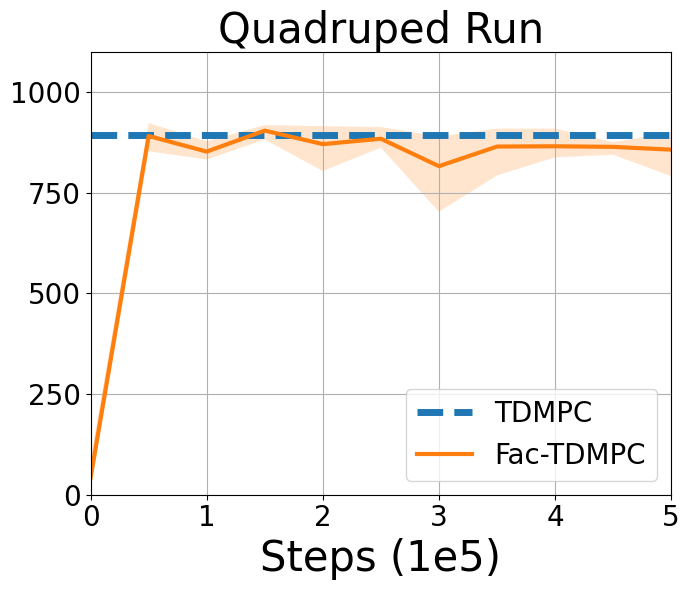

In [166]:
exp_name = "quadruped-run"
expert_value = 894.7
results = load_results(exp_names={'Fac-TDMPC': exp_name})
fig = plot_curves(exp_name, results, {"TDMPC": expert_value})

fig.savefig(OUTPUT_DIR+f'/{exp_name}.png', dpi=300)

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import os

BASE_DIR = 'exp_results'
OUTPUT_DIR = 'figures'


def draw_plot(y_fac, y_tdmpc, x, xlabel="x"):
    y_fac = list(zip(*y_fac))      # [(mean1, mean2, ...), (std1, std2, ...)]
    y_tdmpc = list(zip(*y_tdmpc))  # same

    # Extract mean and std
    fac_mean, fac_std = y_fac
    tdmpc_mean, tdmpc_std = y_tdmpc

    x_min, x_max = np.min(x), np.max(x)

    plt.figure(figsize=(7, 6))
    # plt.errorbar(x, tdmpc_mean, yerr=tdmpc_std, label='TDMPC', fmt='-s', capsize=5)
    # plt.errorbar(x, fac_mean, yerr=fac_std, label='Fac-TDMPC', fmt='-o', capsize=5)
    plt.plot(x, tdmpc_mean, label='TDMPC', linewidth=3.0)
    plt.plot(x, fac_mean, label='Fac-TDMPC', linewidth=3.0)

    plt.xlabel(xlabel.replace("_", " ").title(), fontsize=30, labelpad=10)
    # plt.ylim((y_min, y_max))
    plt.xlim((x_min, x_max))
    plt.tick_params(labelsize=25)

    # plt.ylabel("Episode Return", fontsize=30)
    plt.legend(fontsize=20, loc="lower right")

    ax = plt.gca()
    ax.grid(True, linestyle='--')
    # ax.xaxis.set_major_locator(MaxNLocator(nbins=4))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4))  
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, xlabel+".png"))


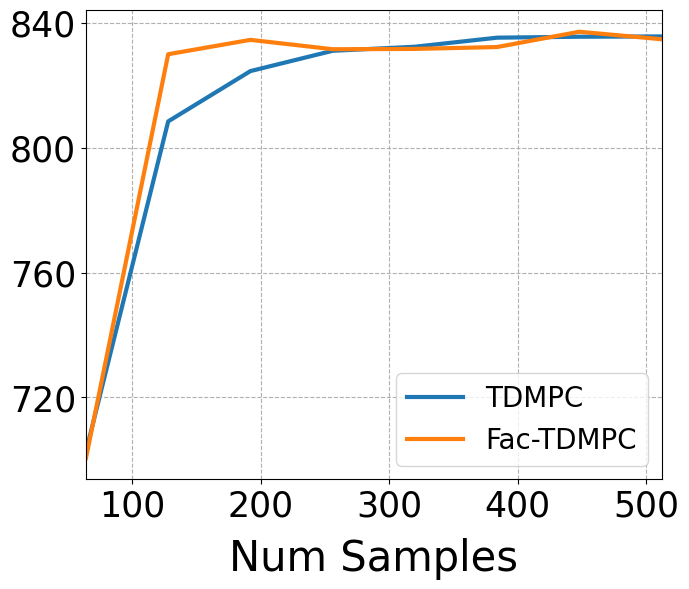

In [5]:
# 128: 829,9, 512: 820.6 - > 824.7
y_fac = np.array([[690.6, 73.2], [819.9, 12.39], [824.5, 18.8], [821.5, 20.5], [821.6, 14.1], [822.2, 12.3], [827.1, 12.1], [824.7, 13.9]]) + 10.0
y_tdmpc = [[702.7, 35.9], [808.4, 15.5], [824.5, 7.6], [831.0, 6.7], [832.3, 7.5], [835.2, 6.8], [835.5, 7.9], [835.6, 7.0]]
x = [64, 128, 192, 256, 320, 384, 448, 512]

draw_plot(y_fac, y_tdmpc, x, "num_samples")


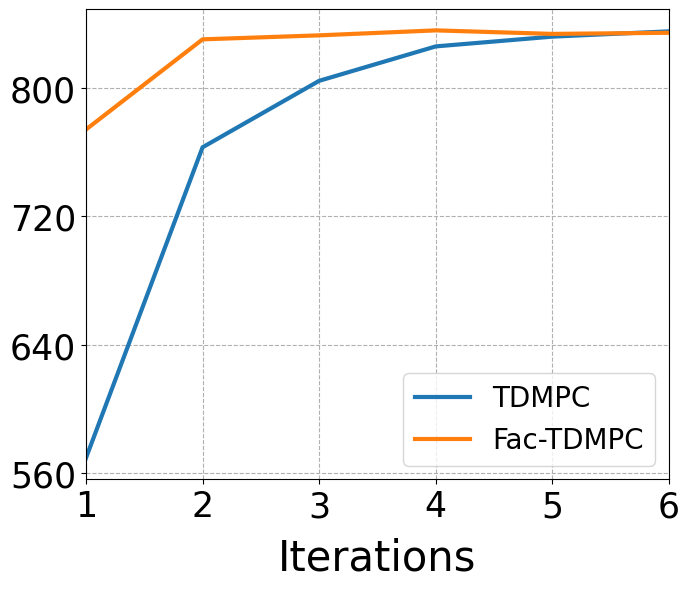

In [188]:
# 6: 820.6 -> 824.7
y_fac = np.array([[764.3 , 16.1], [820.6 , 17.8], [823.1 , 16.7], [826.2 , 6.1], [824.0 , 12.4], [824.7 , 13.9 ]]) + 10.0
y_tdmpc = [[569.2 , 28.9], [763.2 , 21.2 ], [804.7 , 19.6], [826.2 , 6.1], [832.3, 7.5], [835.6, 7.0]]
x = [1, 2, 3, 4, 5, 6]

draw_plot(y_fac, y_tdmpc, x, "iterations")

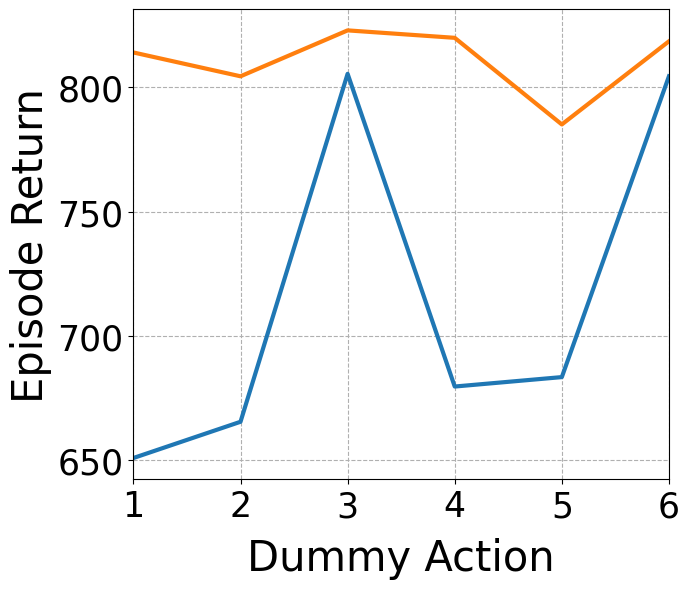

In [90]:
y_fac = np.array([[804.1 , 23.4], [794.5 , 20.7], [813.0 , 15.4], [810.0 , 21.1], [775.1 , 53.6], [808.6 , 19.3]]) + 10.0
y_tdmpc = [[650.7 , 45.1 ], [665.3 , 28.4 ], [805.5 , 6.5], [679.5 , 29.2], [683.3 , 14.], [804.5 , 20.8]]
x = [1, 2, 3, 4, 5, 6]

draw_plot(y_fac, y_tdmpc, x, "dummy_action")



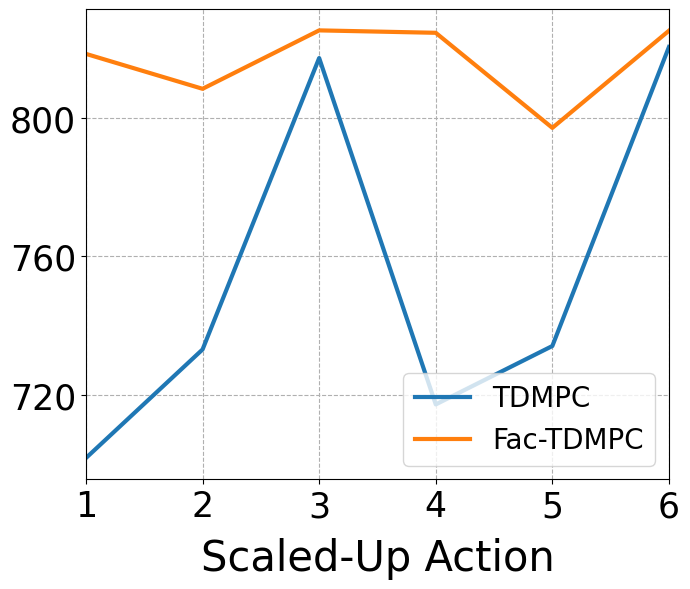

In [ ]:
y_fac = np.array([784.7 , 11.4  804.7 , 20.0 813.0 , 26.1 781.0 , 16.6  740.0 , 54.9  816.7 , 16.4]) + 10.0
y_tdmpc = [[678.0 , 18.5], [765.3 , 15.3],  [776.5 , 19.9], [711.4 , 12.0], [730.3 , 20.0], [834.0 , 8.1 ]]
x = [1, 2, 3, 4, 5, 6]

draw_plot(y_fac, y_tdmpc, x, "scaled-up_action")





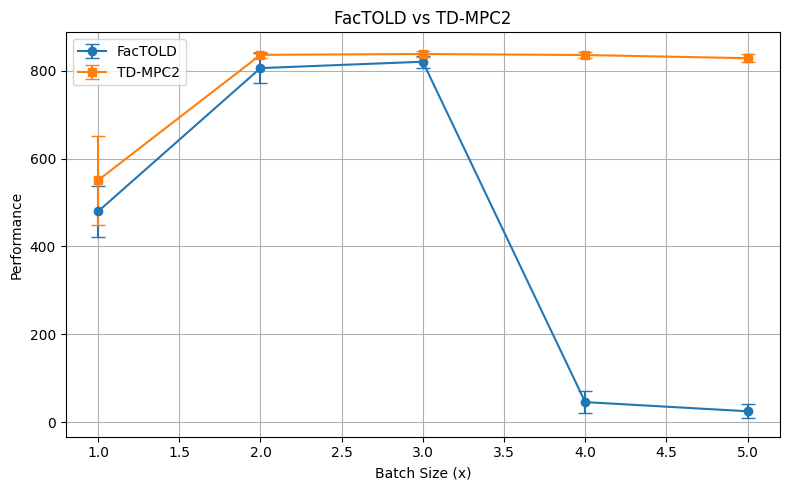

In [7]:
y_fac = [[479.8 , 58.2], [806.2 , 34.1], [820.7 , 13.9], [45.4 , 25.8], [24.5 , 16.1]]
y_tdmpc = [[550.8 , 100.9], [836.4 , 7.5], [838.3 , 7.5 ], [836.0 , 7.8], [828.7 , 8.7 ]]
x = [1, 2, 3, 4, 5]

draw_plot(y_fac, y_tdmpc, x)